# Machine Learning Classification of Player Feedback from Steam Reviews

**Student:** Robert Mayfield  
**Project:** Udacity AI Masters Capstone - Applied Machine Learning  

In [1]:
import re
import sys
import json
import time
import string
import pickle
import logging
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.naive_bayes import ComplementNB, MultinomialNB
from sklearn.svm import LinearSVC

# aif360 emits noisy optional dependency warnings on import; suppress and restore
logging.getLogger().setLevel(logging.ERROR)
from aif360.datasets import BinaryLabelDataset
from aif360.metrics import ClassificationMetric
logging.getLogger().setLevel(logging.WARNING)

sys.path.insert(0, '..')
from src.inspection import inspect_dataframe
from src.preprocessing import preprocess_text, build_feature_matrix
from src.evaluation import evaluate_model

## 1. Project Overview

This project trains a supervised binary text classifier to predict whether a Steam game review is positive or negative, using the reviewer applied `voted_up` label from the Steam Reviews Dataset as ground truth (forgemaster, 2021). The trained classifier and TF-IDF vectorizer are saved as reusable artifacts in `outputs/model_artifacts/`.

## 2. Dataset Loading and Inspection

In [2]:
RANDOM_SEED   = 42
TARGET_SAMPLE = 100_000
RAW_ZIP   = Path('../data/raw/archive.zip')
PROCESSED = Path('../data/processed/steam_reviews_sample.csv')
SAMPLE    = Path('../data/sample/steam_reviews_1k.csv')

print(f"Raw archive present: {RAW_ZIP.exists()}")
print(f"Processed sample present: {PROCESSED.exists()}")

Raw archive present: True
Processed sample present: True


In [3]:
if PROCESSED.exists():
    print("Processed sample found - skipping extraction.")
    df = pd.read_csv(PROCESSED)
else:
    print("Building processed sample from archive...")
    PROCESSED.parent.mkdir(parents=True, exist_ok=True)

    frames = []
    with zipfile.ZipFile(RAW_ZIP) as z:
        csv_files = [f for f in z.namelist() if f.endswith('.csv')]
        print(f"CSV files in archive: {len(csv_files)}")
        for name in csv_files:
            with z.open(name) as fh:
                chunk = pd.read_csv(fh, usecols=['appid', 'review', 'voted_up'],
                                    low_memory=False)
                frames.append(chunk)
                print(f"  Loaded {name}: {len(chunk):,} rows")

    raw = pd.concat(frames, ignore_index=True)
    print(f"\nTotal rows: {len(raw):,}")

    raw = raw.dropna(subset=['review', 'voted_up']).reset_index(drop=True)
    raw['voted_up'] = raw['voted_up'].astype(bool)

    pos = raw[raw['voted_up'] == True]
    neg = raw[raw['voted_up'] == False]
    n_pos = int(TARGET_SAMPLE * len(pos) / len(raw))
    n_neg = int(TARGET_SAMPLE * len(neg) / len(raw))
    sample = pd.concat([
        pos.sample(n=min(len(pos), n_pos), random_state=RANDOM_SEED),
        neg.sample(n=min(len(neg), n_neg), random_state=RANDOM_SEED),
    ]).reset_index(drop=True)

    sample.to_csv(PROCESSED, index=False)
    print(f"Saved: {len(sample):,} rows to {PROCESSED}")
    df = sample

print(f"\nDataset loaded: {len(df):,} rows, {df.shape[1]} columns")

Processed sample found - skipping extraction.

Dataset loaded: 99,999 rows, 3 columns


In [4]:
if not SAMPLE.exists():
    SAMPLE.parent.mkdir(parents=True, exist_ok=True)
    df.sample(n=1000, random_state=RANDOM_SEED).to_csv(SAMPLE, index=False)
    print(f"Saved 1k sample → {SAMPLE}")
else:
    print("1k sample already exists.")

1k sample already exists.


In [5]:
inspect_dataframe(df)

SHAPE AND STRUCTURE
------------------------------------------------------------
Rows:    99,999
Columns: 3

COLUMN NAMES AND DATA TYPES
------------------------------------------------------------
appid       int64
voted_up     bool
review        str

MEMORY USAGE
------------------------------------------------------------
Total: 32.03 MB

MISSING VALUES
------------------------------------------------------------
No missing values found.

DUPLICATE ROWS
------------------------------------------------------------
Duplicate rows: 2,882

DESCRIPTIVE STATISTICS (NUMERIC)
------------------------------------------------------------
              appid
count  9.999900e+04
mean   3.050983e+05
std    2.141970e+05
min    1.000000e+01
25%    2.037700e+05
50%    2.836800e+05
75%    4.183700e+05
max    1.046030e+06

DESCRIPTIVE STATISTICS (CATEGORICAL)
------------------------------------------------------------
       review
count   99999
unique  89199
top      good
freq      592

UNIQUE VALU

In [6]:
counts = df['voted_up'].value_counts()
pct    = df['voted_up'].value_counts(normalize=True) * 100
print("Class distribution")
print(f"  Positive (voted_up=True):  {counts[True]:>7,}  ({pct[True]:.1f}%)")
print(f"  Negative (voted_up=False): {counts[False]:>7,}  ({pct[False]:.1f}%)")

Class distribution
  Positive (voted_up=True):   86,944  (86.9%)
  Negative (voted_up=False):  13,055  (13.1%)


The sample contains 99,999 rows across 3 columns (appid, review, voted_up) with no missing values, confirming the dataset is clean on ingestion. Memory usage is 32.03 MB, which is manageable in memory without chunking.

The dataset is strongly class imbalanced: 86,944 positive reviews (86.9%) versus 13,055 negative reviews (13.1%), a ratio of roughly 6.7 to 1. This imbalance reflects real Steam user behavior but means a naive classifier that predicts positive for every review would achieve 86.9% accuracy without learning anything meaningful. Evaluation will therefore emphasize macro F1 score, which weights each class equally regardless of support.

Exact duplicate rows are present in the sample, most being short positive reviews appearing across multiple data files rather than data entry errors. The full duplicate count and removal are handled in the data quality review in Section 3.

## 3. Data Quality Review

In [7]:
df['char_count'] = df['review'].str.len()
df['word_count'] = df['review'].str.split().str.len()

print("Character count:")
print(df['char_count'].describe().round(1).to_string())
print()
print("Word count:")
print(df['word_count'].describe().round(1).to_string())

Character count:
count    99999.0
mean       258.5
std        576.8
min          1.0
25%         22.0
50%         75.0
75%        241.0
max       8000.0

Word count:
count    99999.0
mean        47.1
std        103.2
min          0.0
25%          4.0
50%         14.0
75%         44.0
max       1527.0


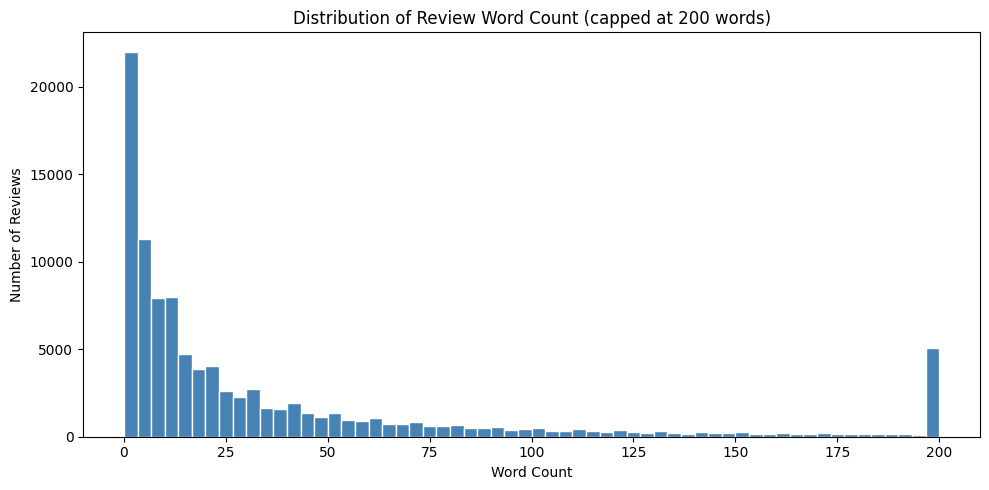

Saved: ..\outputs\figures\review_length_distribution.png


In [8]:
FIGURES = Path('../outputs/figures')
FIGURES.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 5))
capped = df['word_count'].clip(upper=200)
ax.hist(capped, bins=60, color='steelblue', edgecolor='white')
ax.set_title('Distribution of Review Word Count (capped at 200 words)')
ax.set_xlabel('Word Count')
ax.set_ylabel('Number of Reviews')
plt.tight_layout()
out = FIGURES / 'review_length_distribution.png'
plt.savefig(out, dpi=150)
plt.show()
print(f"Saved: {out}")

In [9]:
print(f"{'Threshold':<22} {'Count':>8}  {'Percent':>8}")
print("-" * 42)
for t in [3, 5, 10]:
    n = (df['word_count'] < t).sum()
    pct = n / len(df) * 100
    print(f"Under {t} words{'':<14} {n:>8,}  ({pct:>5.1f}%)")

Threshold                 Count   Percent
------------------------------------------
Under 3 words                 16,853  ( 16.9%)
Under 5 words                 26,602  ( 26.6%)
Under 10 words                 41,228  ( 41.2%)


In [10]:
print(f"Maximum character count:          {df['char_count'].max():,}")
print(f"Reviews at exactly 8,000 chars:   {(df['char_count'] == 8000).sum():,}")
print(f"Reviews over 8,000 chars:         {(df['char_count'] > 8000).sum():,}")
print(f"Maximum word count:               {df['word_count'].max():,}")

Maximum character count:          8,000
Reviews at exactly 8,000 chars:   2
Reviews over 8,000 chars:         0
Maximum word count:               1,527


In [11]:
short = df[df['word_count'] < 3][['review', 'voted_up', 'word_count']].head(15)
print(f"Sample of reviews with fewer than 3 words ({(df['word_count'] < 3).sum():,} total):")
print()
print(short.to_string())

Sample of reviews with fewer than 3 words (16,853 total):

           review  voted_up  word_count
11              A      True           1
14    good game\n      True           2
17         Its ok      True           2
25            Yes      True           1
28          Great      True           1
34          its g      True           2
35     Great game      True           2
40    fun game \n      True           2
42           Cool      True           1
43  Damn Khergits      True           2
46        catgirl      True           1
50         mantap      True           1
54              .      True           1
64            ggs      True           1
68          heyoo      True           1


In [12]:
html_pattern = re.compile(r'<[a-zA-Z/][^>]*>')
url_pattern  = re.compile(r'https?://')

df['has_html'] = df['review'].str.contains(html_pattern, regex=True)
df['has_url']  = df['review'].str.contains(url_pattern, regex=True)

print(f"Reviews containing HTML tags: {df['has_html'].sum():,}  ({df['has_html'].mean()*100:.2f}%)")
print(f"Reviews containing URLs:      {df['has_url'].sum():,}  ({df['has_url'].mean()*100:.2f}%)")
print()
print("Sample reviews with HTML:")
for r in df[df['has_html']]['review'].head(3).tolist():
    print(f"  {r[:120]}")
print()
print("Sample reviews with URLs:")
for r in df[df['has_url']]['review'].head(3).tolist():
    print(f"  {r[:120]}")

Reviews containing HTML tags: 31  (0.03%)
Reviews containing URLs:      557  (0.56%)

Sample reviews with HTML:
  I spent the first twelve minutes of this game shooting clouds and tumbleweeds and getting a meat bounty of 9011.  I'm se
  <h1>AWESOME!</h1>

It's even better than Arkham Asylum.

Great story, very good graphics, fantastic voice acting.

Unfor
  Battlefield 1: run in guns blazing, you win.
Verdun: run in guns bla- SH*T MORTARS--- <DEAD>

Sample reviews with URLs:
  [b]PROS:[/b]
+ awesome and long story
+ cool mix between historical settings and Animus UI
+ huge maps (five cities + ex
  There isn't much I can say about Half-Life 2: lost Coast that hasn't been said already. It's a short mission cut from th
  Nerdcubed put it best "It's got one idea and it does it well" 
If you don't know who Nerdcubed is (I can't imagine how) 


In [13]:
df['non_ascii_ratio'] = (
    df['review'].str.count(r'[^\x00-\x7F]') /
    df['review'].str.len().clip(lower=1)
)

thresholds = [0.1, 0.3, 0.5]
print(f"{'Non-ASCII ratio threshold':<30} {'Count':>8}  {'Percent':>8}")
print("-" * 50)
for t in thresholds:
    n = (df['non_ascii_ratio'] > t).sum()
    pct = n / len(df) * 100
    print(f"More than {t:.0%} non-ASCII{'':<12} {n:>8,}  ({pct:>5.1f}%)")
print()
print("Sample high non-ASCII reviews (ratio > 0.3):")
for r in df[df['non_ascii_ratio'] > 0.3]['review'].head(5).tolist():
    print(f"  {r[:120]}")

Non-ASCII ratio threshold         Count   Percent
--------------------------------------------------
More than 10% non-ASCII                  774  (  0.8%)
More than 30% non-ASCII                  622  (  0.6%)
More than 50% non-ASCII                  542  (  0.5%)

Sample high non-ASCII reviews (ratio > 0.3):
  When the balloons and you is sus! 😳
⠀⠀⠀⡯⡯⡾⠝⠘⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢊⠘⡮⣣⠪⠢⡑⡌
⠀⠀⠀⠟⠝⠈⠀⠀⠀⠡⠀⠠⢈⠠⢐⢠⢂⢔⣐⢄⡂⢔⠀⡁⢉⠸⢨⢑⠕⡌
⠀⠀⡀⠁⠀⠀⠀⡀⢂⠡⠈⡔⣕⢮⣳⢯⣿⣻⣟⣯⣯⢷
  Як Portal тільки простіше і про "живих" роботів ¯\_(ツ)_/¯
  ❶ ❷ ❸ ❹ ❺
  เเจ้มเเมวสุดๆ สนุกลุ้นใจ สยบใจ มาหาเกิด กรุจะเยอะละ
  ­


In [14]:
exact_dups = df.duplicated(subset=['review']).sum()
print(f"Duplicate rows (exact review text match): {exact_dups:,}  ({exact_dups/len(df)*100:.1f}%)")
print()

top_dups = (
    df[df.duplicated(subset=['review'], keep=False)]
    .groupby('review')
    .agg(count=('voted_up', 'count'), pct_positive=('voted_up', 'mean'))
    .sort_values('count', ascending=False)
    .head(10)
)
top_dups['pct_positive'] = (top_dups['pct_positive'] * 100).round(1)
print("Most common duplicate review texts:")
print(top_dups.to_string())

Duplicate rows (exact review text match): 10,800  (10.8%)

Most common duplicate review texts:
            count  pct_positive
review                         
good          592         100.0
yes           495          99.8
good game     406          99.3
.             253          92.1
fun           225          99.6
nice          185         100.0
great game    166         100.0
Good game     150         100.0
Great game    142         100.0
10/10         134         100.0


Overall class distribution:
  Positive (voted_up=True):   86,944  (86.9%)
  Negative (voted_up=False):  13,055  (13.1%)

Positive rate by review length group (3+ word reviews):
  Short (3-24 words)      41,261 / 45,959  (89.8% positive)
  Long (25+ words)        29,806 / 37,187  (80.2% positive)


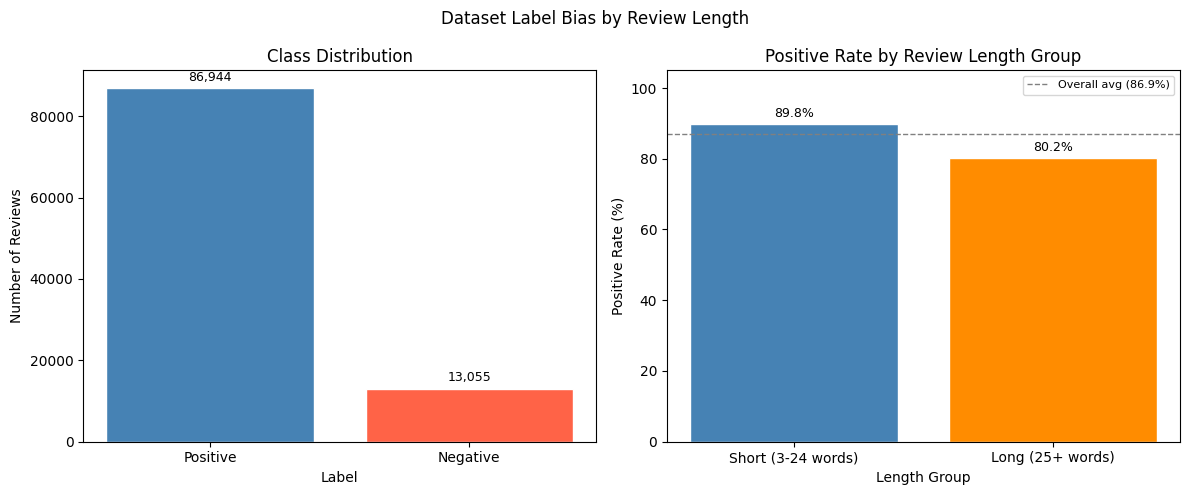


Saved: ..\outputs\figures\class_distribution.png


In [15]:
# Use reviews that will survive the word count filter (3+ words)
df_bias_check = df[df['word_count'] >= 3].copy()
df_bias_check['length_group'] = np.where(
    df_bias_check['word_count'] < 25, 'Short (3-24 words)', 'Long (25+ words)'
)

pos_count = int(df['voted_up'].sum())
neg_count = int((~df['voted_up']).sum())

group_stats = (
    df_bias_check.groupby('length_group', sort=False)['voted_up']
    .agg(total='count', positive='sum')
    .assign(positive_rate=lambda d: d['positive'] / d['total'] * 100)
    .loc[['Short (3-24 words)', 'Long (25+ words)']]
)

print("Overall class distribution:")
print(f"  Positive (voted_up=True):  {pos_count:>7,}  ({pos_count/len(df)*100:.1f}%)")
print(f"  Negative (voted_up=False): {neg_count:>7,}  ({neg_count/len(df)*100:.1f}%)")
print()
print("Positive rate by review length group (3+ word reviews):")
for g, row in group_stats.iterrows():
    print(f"  {g:<22}  {int(row['positive']):>6,} / {int(row['total']):>6,}  ({row['positive_rate']:.1f}% positive)")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
bars = ax.bar(['Positive', 'Negative'], [pos_count, neg_count],
              color=['steelblue', 'tomato'], edgecolor='white')
ax.set_title('Class Distribution')
ax.set_xlabel('Label')
ax.set_ylabel('Number of Reviews')
ax.bar_label(bars, fmt='{:,.0f}', padding=3, fontsize=9)

ax = axes[1]
groups_list = group_stats.index.tolist()
rates = group_stats['positive_rate'].tolist()
overall_rate = df['voted_up'].mean() * 100
bars2 = ax.bar(groups_list, rates, color=['steelblue', 'darkorange'], edgecolor='white')
ax.axhline(overall_rate, color='gray', linewidth=1, linestyle='--',
           label=f'Overall avg ({overall_rate:.1f}%)')
ax.set_title('Positive Rate by Review Length Group')
ax.set_xlabel('Length Group')
ax.set_ylabel('Positive Rate (%)')
ax.set_ylim(0, 105)
ax.legend(fontsize=8)
ax.bar_label(bars2, fmt='%.1f%%', padding=3, fontsize=9)

plt.suptitle('Dataset Label Bias by Review Length')
plt.tight_layout()
out = FIGURES / 'class_distribution.png'
plt.savefig(out, dpi=150)
plt.show()
print(f"\nSaved: {out}")

**Class imbalance.** The dataset is strongly skewed toward positive reviews: 86,944 positive (86.9%) versus 13,055 negative (13.1%), a ratio of roughly 6.7 to 1. This reflects real Steam platform behavior but represents a significant source of label bias. A naive classifier that always predicts positive would achieve 86.9% accuracy without learning any meaningful signal. This imbalance will be addressed at the model level using `class_weight='balanced'` for the linear classifiers, which rescales each class's contribution to the loss function in inverse proportion to its frequency.

**Label bias by review length.** Short reviews (3 to 24 words) are 89.8% positive, while long reviews (25 or more words) are 80.2% positive, a gap of nearly 10 percentage points. Users who leave brief reviews skew heavily toward positive sentiment; players who invest time writing longer reviews tend to articulate specific criticisms more often. Any model trained on this data will see a systematically different label distribution depending on review length. This subgroup label disparity is evaluated post-training in Section 11 using the AIF360 fairness toolkit.

Key quality findings: 16,853 reviews (16.9%) contain fewer than 3 words and will be filtered; 10,800 (10.8%) are exact text duplicates, mostly short positive reviews that will be dropped after the word count filter; 31 reviews contain HTML tags and 557 contain URLs, both stripped during preprocessing; 622 reviews (0.6%) exceed a 30% non-ASCII ratio and their non-ASCII characters will be removed. No reviews exceed Steam's 8,000 character cap, so no upper length filter is needed.

## 4. Text and Feature Preprocessing

Text preprocessing and feature extraction are handled by two functions defined in `src/preprocessing.py` and imported at the top of the notebook.

- **`preprocess_text(text)`** - lowercases, strips HTML tags, BBCode markup, URLs, non-ASCII characters, and punctuation, then collapses whitespace.
- **`build_feature_matrix(df, vectorizer=None)`** - vectorizes the `review_clean` column using TF-IDF (50,000 features, unigrams and bigrams, sublinear TF scaling). Fits a new vectorizer when called on the training set; transforms without refitting when a fitted vectorizer is passed.

In [16]:
n_before = len(df)

# Drop reviews under 3 words (near-empty TF-IDF vectors)
df = df[df['word_count'] >= 3].copy()
n_after_len = len(df)

# Drop text-level duplicates (keep first occurrence)
df = df.drop_duplicates(subset=['review']).reset_index(drop=True)
n_after_dedup = len(df)

print(f"Rows before filtering:          {n_before:>8,}")
print(f"After word count filter (>=3):  {n_after_len:>8,}  (-{n_before - n_after_len:,})")
print(f"After text deduplication:       {n_after_dedup:>8,}  (-{n_after_len - n_after_dedup:,})")
print(f"Total removed:                  {n_before - n_after_dedup:>8,}  ({(n_before - n_after_dedup)/n_before*100:.1f}%)")

Rows before filtering:            99,999
After word count filter (>=3):    83,146  (-16,853)
After text deduplication:         81,805  (-1,341)
Total removed:                    18,194  (18.2%)


In [17]:
df['review_clean'] = df['review'].apply(preprocess_text)

print("Sample preprocessing output (first 5 reviews):")
print()
for _, row in df.head(5).iterrows():
    print(f"  BEFORE: {row['review'][:100]}")
    print(f"  AFTER:  {row['review_clean'][:100]}")
    print()

Sample preprocessing output (first 5 reviews):

  BEFORE: If anything SOMA has a fantastic story. Every aspect of its story is really engaging and well done. 
  AFTER:  if anything soma has a fantastic story every aspect of its story is really engaging and well done th

  BEFORE: One of the best games I have ever played.




10/10
  AFTER:  one of the best games i have ever played 1010

  BEFORE: This game is an incredible experience. I recommend it to anyone, I binged it in 3 hours and was amaz
  AFTER:  this game is an incredible experience i recommend it to anyone i binged it in 3 hours and was amazin

  BEFORE: one of the best games you'll never play.
  AFTER:  one of the best games youll never play

  BEFORE: This game is still rough, but damn, does it ever have potential to be amazing.

Play PvPvE on multip
  AFTER:  this game is still rough but damn does it ever have potential to be amazing play pvpve on multiplaye



In [18]:
counts = df['voted_up'].value_counts()
pct    = df['voted_up'].value_counts(normalize=True) * 100
print(f"Clean dataset: {len(df):,} rows, {df.shape[1]} columns")
print()
print("Class distribution after filtering:")
print(f"  Positive (voted_up=True):  {counts[True]:>7,}  ({pct[True]:.1f}%)")
print(f"  Negative (voted_up=False): {counts[False]:>7,}  ({pct[False]:.1f}%)")

Clean dataset: 81,805 rows, 9 columns

Class distribution after filtering:
  Positive (voted_up=True):   69,749  (85.3%)
  Negative (voted_up=False):  12,056  (14.7%)


**Filtering results.** The word count filter removed 16,853 rows; text deduplication removed an additional 1,341, leaving 81,805 reviews. After filtering, the class distribution shifted from 86.9% / 13.1% to 85.3% positive / 14.7% negative. Short reviews were disproportionately positive, so removing them marginally reduced the imbalance. The preprocessing sample confirms `preprocess_text` is working as expected.

## 5. Model Candidates

Four candidate models are trained on the same TF-IDF features. All are linear or probabilistic classifiers appropriate for sparse input; tree based models are excluded as computationally inefficient on TF-IDF matrices. Macro F1 is the selection criterion; `class_weight='balanced'` is applied to the linear classifiers.

| Model | Key characteristic |
|---|---|
| Logistic Regression (L2, C=1.0) | Linear classifier; interpretable coefficients; native `class_weight` support; calibrated probability output |
| Linear SVM (LinearSVC, C=1.0) | Maximum margin linear classifier; strong baseline for text; no native probability output |
| Multinomial Naive Bayes (alpha=1.0) | Probabilistic; assumes feature independence; very fast; well-established for text classification |
| Complement Naive Bayes (alpha=1.0) | Designed for imbalanced class distributions; estimates each class using data from all other classes |

In [19]:
candidates = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=RANDOM_SEED,
        solver='lbfgs',
        C=1.0,
    ),
    'Linear SVM': LinearSVC(
        class_weight='balanced',
        max_iter=2000,
        random_state=RANDOM_SEED,
        C=1.0,
    ),
    'Multinomial NB': MultinomialNB(alpha=1.0),
    'Complement NB':  ComplementNB(alpha=1.0),
}

print("Candidate models defined:")
for name in candidates:
    print(f"  {name}")

Candidate models defined:
  Logistic Regression
  Linear SVM
  Multinomial NB
  Complement NB


## 6. Train/Test Split

In [20]:
df_train, df_test = train_test_split(
    df,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=df['voted_up'],
)
df_train = df_train.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

for name, subset in [('Train', df_train), ('Test', df_test)]:
    counts = subset['voted_up'].value_counts()
    pct    = subset['voted_up'].value_counts(normalize=True) * 100
    print(f"{name} set: {len(subset):,} rows")
    print(f"  Positive: {counts[True]:,} ({pct[True]:.1f}%)")
    print(f"  Negative: {counts[False]:,} ({pct[False]:.1f}%)")
    print()

Train set: 65,444 rows
  Positive: 55,799 (85.3%)
  Negative: 9,645 (14.7%)

Test set: 16,361 rows
  Positive: 13,950 (85.3%)
  Negative: 2,411 (14.7%)



In [21]:
X_train, y_train, vectorizer = build_feature_matrix(df_train)
X_test,  y_test,  _          = build_feature_matrix(df_test, vectorizer)

print()
print(f"Vocabulary size: {len(vectorizer.vocabulary_):,} terms")
print(f"X_train shape:   {X_train.shape}")
print(f"X_test  shape:   {X_test.shape}")

Fit + transformed: 65,444 reviews x 50,000 features
Transformed: 16,361 reviews x 50,000 features

Vocabulary size: 50,000 terms
X_train shape:   (65444, 50000)
X_test  shape:   (16361, 50000)


The 81,805 row clean dataset was split into 65,444 training rows and 16,361 test rows (80/20). Stratification on `voted_up` preserved the class distribution exactly: both sets are 85.3% positive and 14.7% negative, ensuring the test set reflects the same imbalance the model will encounter in practice.

The TF-IDF vectorizer was fit on the training set only and hit the 50,000 feature cap, confirming the corpus vocabulary is large enough that the cap is the binding constraint rather than data size. The test set was transformed using the training vocabulary without refitting. This prevents any information about test set term frequencies from influencing the feature weights, maintaining a clean held out evaluation.

## 7. Model Training

Model evaluation is handled by `evaluate_model(model, X_test, y_test, training_time=None)`, defined in `src/evaluation.py` and imported at the top of the notebook. It returns accuracy, macro and per class precision, recall, and F1, confusion matrix, predictions, and training time as a dictionary.

In [22]:
trained = {}

for name, model in candidates.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - t0
    trained[name] = {'model': model, 'training_time': elapsed}
    print(f"  {name:<25} {elapsed:.2f}s")

print()
print("All models trained.")

  Logistic Regression       0.80s
  Linear SVM                1.92s
  Multinomial NB            0.03s
  Complement NB             0.03s

All models trained.


## 8. Model Evaluation

In [23]:
TABLES  = Path('../outputs/tables')
FIGURES = Path('../outputs/figures')
TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

results = {}
for name, entry in trained.items():
    results[name] = evaluate_model(
        entry['model'], X_test, y_test,
        training_time=entry['training_time'],
    )

rows = []
for name, r in results.items():
    rows.append({
        'model':            name,
        'accuracy':         round(r['accuracy'], 4),
        'precision_macro':  round(r['precision_macro'], 4),
        'recall_macro':     round(r['recall_macro'], 4),
        'f1_macro':         round(r['f1_macro'], 4),
        'training_time_s':  round(r['training_time'], 3),
    })

metrics_df = pd.DataFrame(rows).sort_values('f1_macro', ascending=False).reset_index(drop=True)
metrics_df.to_csv(TABLES / 'model_metrics.csv', index=False)

print(metrics_df.to_string(index=False))
print()
print(f"Saved: outputs/tables/model_metrics.csv")

              model  accuracy  precision_macro  recall_macro  f1_macro  training_time_s
         Linear SVM    0.9059           0.8064        0.8470    0.8245            1.916
Logistic Regression    0.8936           0.7847        0.8717    0.8175            0.801
      Complement NB    0.8889           0.7764        0.8230    0.7965            0.031
     Multinomial NB    0.8789           0.8847        0.5995    0.6322            0.032

Saved: outputs/tables/model_metrics.csv


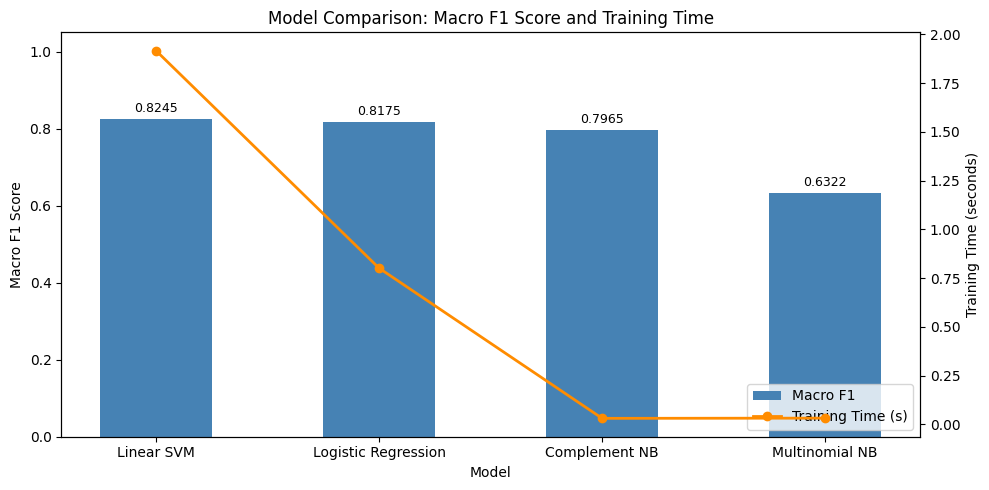

Saved: ..\outputs\figures\model_comparison.png


In [24]:
model_names = metrics_df['model'].tolist()
f1_scores   = metrics_df['f1_macro'].tolist()
train_times = metrics_df['training_time_s'].tolist()

x = np.arange(len(model_names))

fig, ax1 = plt.subplots(figsize=(10, 5))
bars = ax1.bar(x, f1_scores, color='steelblue', width=0.5, label='Macro F1')
ax1.set_xticks(x)
ax1.set_xticklabels(model_names)
ax1.set_xlabel('Model')
ax1.set_ylabel('Macro F1 Score')
ax1.set_ylim(0, 1.05)
ax1.set_title('Model Comparison: Macro F1 Score and Training Time')
ax1.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)

ax2 = ax1.twinx()
ax2.plot(x, train_times, color='darkorange', marker='o', linewidth=2, label='Training Time (s)')
ax2.set_ylabel('Training Time (seconds)')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right')

plt.tight_layout()
out = FIGURES / 'model_comparison.png'
plt.savefig(out, dpi=150)
plt.show()
print(f"Saved: {out}")

In [25]:
winner_name  = metrics_df.iloc[0]['model']
winner_model = trained[winner_name]['model']
winner_res   = results[winner_name]

print(f"Selected model: {winner_name}")
print(f"  Macro F1:       {winner_res['f1_macro']:.4f}")
print(f"  Accuracy:       {winner_res['accuracy']:.4f}")
print(f"  Training time:  {winner_res['training_time']:.2f}s")

Selected model: Linear SVM
  Macro F1:       0.8245
  Accuracy:       0.9059
  Training time:  1.92s


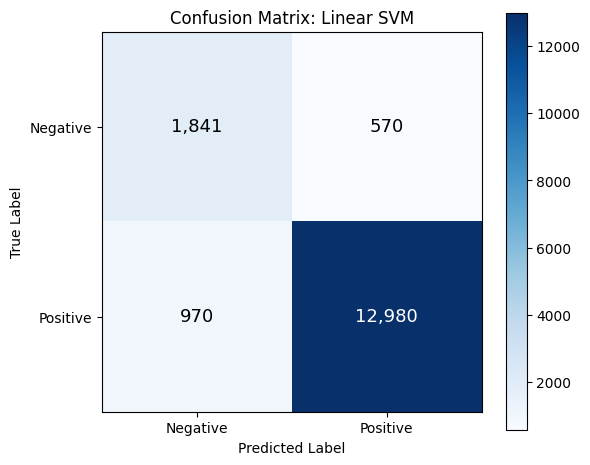

Saved: ..\outputs\figures\confusion_matrix_linear_svm.png


In [26]:
cm     = winner_res['confusion_matrix']
labels = ['Negative', 'Positive']

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
fig.colorbar(im, ax=ax)
ax.set(
    xticks=[0, 1], yticks=[0, 1],
    xticklabels=labels, yticklabels=labels,
    xlabel='Predicted Label',
    ylabel='True Label',
    title=f'Confusion Matrix: {winner_name}',
)
thresh = cm.max() / 2
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm[i, j]:,}',
                ha='center', va='center',
                color='white' if cm[i, j] > thresh else 'black',
                fontsize=13)
plt.tight_layout()
out = FIGURES / f'confusion_matrix_{winner_name.lower().replace(" ", "_")}.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {out}")

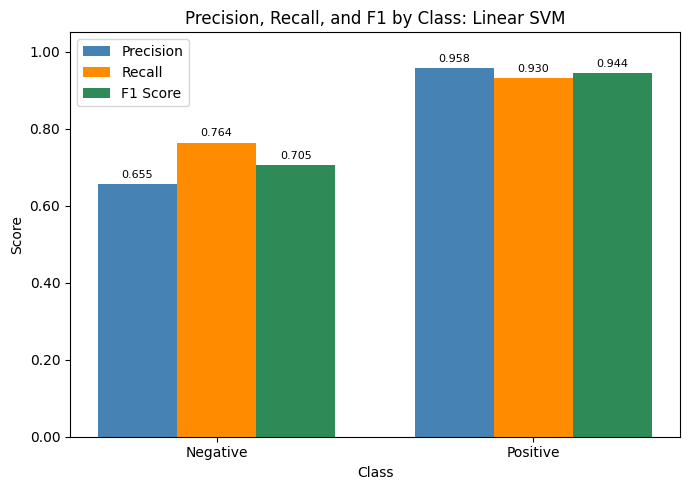

Saved: ..\outputs\figures\metrics_by_class_linear_svm.png


In [27]:
precision = winner_res['precision_per_class']
recall    = winner_res['recall_per_class']
f1        = winner_res['f1_per_class']
labels    = ['Negative', 'Positive']
x         = np.arange(len(labels))
width     = 0.25

fig, ax = plt.subplots(figsize=(7, 5))
b1 = ax.bar(x - width, precision, width, label='Precision', color='steelblue')
b2 = ax.bar(x,         recall,    width, label='Recall',    color='darkorange')
b3 = ax.bar(x + width, f1,        width, label='F1 Score',  color='seagreen')
ax.set(
    xticks=x, xticklabels=labels,
    xlabel='Class',
    ylabel='Score',
    title=f'Precision, Recall, and F1 by Class: {winner_name}',
    ylim=(0, 1.05),
)
ax.legend()
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
for bars in [b1, b2, b3]:
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=8)
plt.tight_layout()
out = FIGURES / f'metrics_by_class_{winner_name.lower().replace(" ", "_")}.png'
plt.savefig(out, dpi=150)
plt.show()
print(f"Saved: {out}")

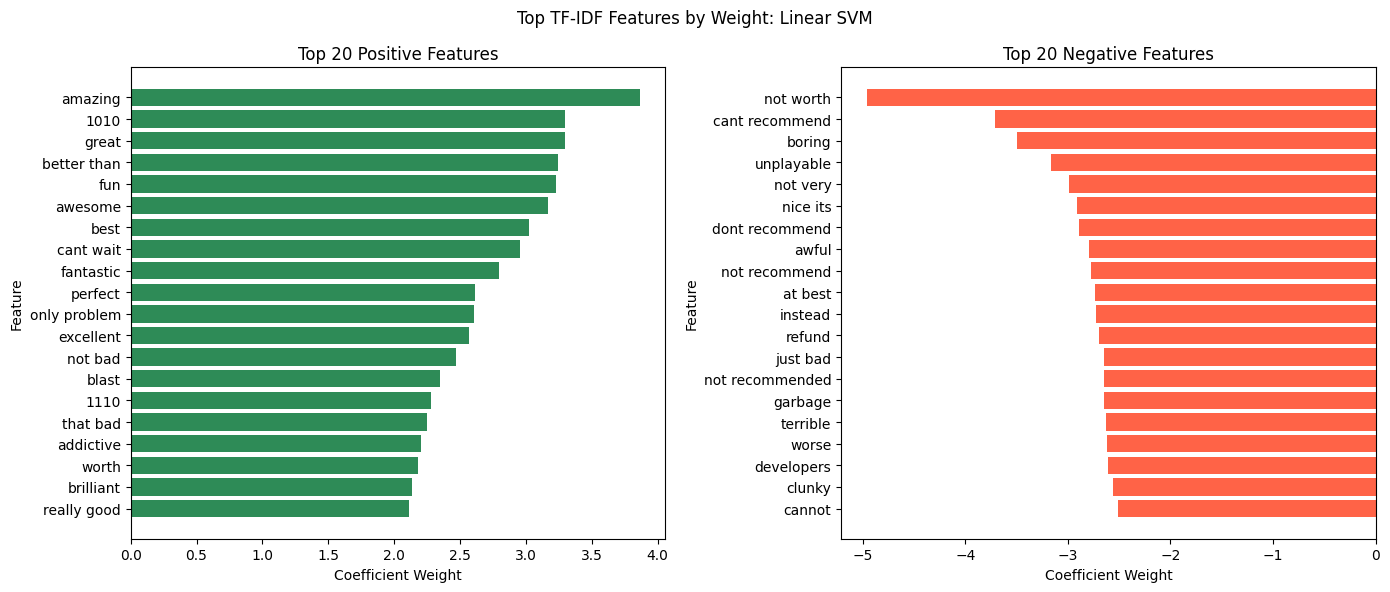

Saved: ..\outputs\figures\top_features_linear_svm.png


In [28]:
if hasattr(winner_model, 'coef_'):
    feature_names = vectorizer.get_feature_names_out()
    coef = winner_model.coef_
    if hasattr(coef, 'toarray'):
        coef = coef.toarray()
    coef = coef.ravel()

    n = 20
    top_pos_idx = np.argsort(coef)[-n:][::-1]
    top_neg_idx = np.argsort(coef)[:n]

    pos_terms   = feature_names[top_pos_idx]
    pos_weights = coef[top_pos_idx]
    neg_terms   = feature_names[top_neg_idx]
    neg_weights = coef[top_neg_idx]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].barh(pos_terms[::-1], pos_weights[::-1], color='seagreen')
    axes[0].set_title(f'Top {n} Positive Features')
    axes[0].set_xlabel('Coefficient Weight')
    axes[0].set_ylabel('Feature')

    axes[1].barh(neg_terms[::-1], neg_weights[::-1], color='tomato')
    axes[1].set_title(f'Top {n} Negative Features')
    axes[1].set_xlabel('Coefficient Weight')
    axes[1].set_ylabel('Feature')

    plt.suptitle(f'Top TF-IDF Features by Weight: {winner_name}')
    plt.tight_layout()
    out = FIGURES / f'top_features_{winner_name.lower().replace(" ", "_")}.png'
    plt.savefig(out, dpi=150)
    plt.show()
    print(f"Saved: {out}")
else:
    print(f"{winner_name} does not expose feature coefficients. Skipping top features chart.")

**Selected model: Linear SVM** (macro F1: 0.8245, accuracy: 90.6%).

| Model | Accuracy | Macro F1 | Training Time |
|---|---|---|---|
| Linear SVM | 0.9059 | **0.8245** | 1.92s |
| Logistic Regression | 0.8936 | 0.8175 | 0.80s |
| Complement NB | 0.8889 | 0.7965 | 0.03s |
| Multinomial NB | 0.8789 | 0.6322 | 0.03s |

A naive classifier predicting positive for every review would achieve 85.3% accuracy. Linear SVM at 90.6% is 5.3 points above that floor, and its macro F1 of 0.8245 reflects meaningful performance on both classes. Multinomial NB's low macro F1 (0.6322) despite high accuracy illustrates why raw accuracy is misleading under class imbalance.

## 9. Hyperparameter Tuning

Linear SVM has one primary hyperparameter that controls the bias variance tradeoff: `C`, the regularization strength. Smaller values of `C` increase regularization and reduce overfitting; larger values relax regularization and let the model fit the training data more closely.

The default value used in Section 8 is `C=1.0`. A cross validated grid search over a range of C values is run on the training set to determine whether a different value improves macro F1. The test set is not used during tuning and remains held out for final evaluation.

In [29]:
param_grid = {'C': [0.01, 0.1, 1.0, 10.0, 100.0]}

base_svm = LinearSVC(
    class_weight='balanced',
    max_iter=2000,
    random_state=RANDOM_SEED,
)

gs = GridSearchCV(
    base_svm,
    param_grid,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
    verbose=1,
)

t0 = time.time()
gs.fit(X_train, y_train)
elapsed = time.time() - t0

print(f"\nGrid search complete in {elapsed:.1f}s")
print(f"Best C:        {gs.best_params_['C']}")
print(f"Best CV macro F1: {gs.best_score_:.4f}")
print()
print("All CV results:")
for mean, std, params in zip(
    gs.cv_results_['mean_test_score'],
    gs.cv_results_['std_test_score'],
    gs.cv_results_['params'],
):
    print(f"  C={params['C']:<8}  F1={mean:.4f}  (+/- {std:.4f})")

Fitting 5 folds for each of 5 candidates, totalling 25 fits

Grid search complete in 156.9s
Best C:        1.0
Best CV macro F1: 0.8237

All CV results:
  C=0.01      F1=0.7684  (+/- 0.0025)
  C=0.1       F1=0.8206  (+/- 0.0044)
  C=1.0       F1=0.8237  (+/- 0.0051)
  C=10.0      F1=0.7949  (+/- 0.0062)
  C=100.0     F1=0.7715  (+/- 0.0069)


In [30]:
best_C = gs.best_params_['C']

t0 = time.time()
tuned_model = LinearSVC(
    C=best_C,
    class_weight='balanced',
    max_iter=2000,
    random_state=RANDOM_SEED,
)
tuned_model.fit(X_train, y_train)
tuned_time = time.time() - t0

tuned_res = evaluate_model(tuned_model, X_test, y_test, training_time=tuned_time)

print(f"Tuned model (C={best_C}) retrained in {tuned_time:.2f}s")
print()
print(f"{'Metric':<20} {'Untuned (C=1.0)':>18} {'Tuned (C=' + str(best_C) + ')':>18}")
print("-" * 58)
baseline = results['Linear SVM']
for label, key in [
    ('Accuracy',       'accuracy'),
    ('Macro Precision','precision_macro'),
    ('Macro Recall',   'recall_macro'),
    ('Macro F1',       'f1_macro'),
]:
    b = baseline[key]
    t = tuned_res[key]
    delta = t - b
    arrow = '+' if delta >= 0 else ''
    print(f"  {label:<18} {b:>18.4f} {t:>18.4f}  ({arrow}{delta:.4f})")

Tuned model (C=1.0) retrained in 1.92s

Metric                  Untuned (C=1.0)      Tuned (C=1.0)
----------------------------------------------------------
  Accuracy                       0.9059             0.9059  (+0.0000)
  Macro Precision                0.8064             0.8064  (+0.0000)
  Macro Recall                   0.8470             0.8470  (+0.0000)
  Macro F1                       0.8245             0.8245  (+0.0000)


In [31]:
winner_model = tuned_model
winner_res   = tuned_res
print(f"winner_model updated to tuned Linear SVM (C={best_C})")
print(f"Final macro F1: {winner_res['f1_macro']:.4f}")

winner_model updated to tuned Linear SVM (C=1.0)
Final macro F1: 0.8245


Grid search confirmed C=1.0 as optimal; test set metrics are identical between the untuned and tuned models.

| C | CV Macro F1 | Std Dev |
|---|---|---|
| 0.01 | 0.7684 | 0.0025 |
| 0.1 | 0.8206 | 0.0044 |
| 1.0 | **0.8237** | 0.0051 |
| 10.0 | 0.7949 | 0.0062 |
| 100.0 | 0.7715 | 0.0069 |

In [32]:
ARTIFACTS = Path('../outputs/model_artifacts')
ARTIFACTS.mkdir(parents=True, exist_ok=True)

with open(ARTIFACTS / 'review_classifier.pkl', 'wb') as f:
    pickle.dump(winner_model, f)

with open(ARTIFACTS / 'tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

label_mapping = {0: 'negative', 1: 'positive'}
with open(ARTIFACTS / 'label_mapping.json', 'w') as f:
    json.dump(label_mapping, f, indent=2)

print("Saved model artifacts:")
print(f"  {ARTIFACTS / 'review_classifier.pkl'}")
print(f"  {ARTIFACTS / 'tfidf_vectorizer.pkl'}")
print(f"  {ARTIFACTS / 'label_mapping.json'}")

Saved model artifacts:
  ..\outputs\model_artifacts\review_classifier.pkl
  ..\outputs\model_artifacts\tfidf_vectorizer.pkl
  ..\outputs\model_artifacts\label_mapping.json


## 10. Error Analysis

In [33]:
df_errors = df_test.copy()
df_errors['y_true'] = y_test
df_errors['y_pred'] = winner_res['y_pred']
df_errors['correct'] = df_errors['y_true'] == df_errors['y_pred']

# false positive: true negative (voted_up=False) predicted positive
# false negative: true positive (voted_up=True) predicted negative
fp = df_errors[(df_errors['y_true'] == 0) & (df_errors['y_pred'] == 1)].copy()
fn = df_errors[(df_errors['y_true'] == 1) & (df_errors['y_pred'] == 0)].copy()

total = len(df_errors)
print(f"Test set total:    {total:,}")
print(f"Correct:           {df_errors['correct'].sum():,}  ({df_errors['correct'].mean()*100:.1f}%)")
print(f"Errors:            {(~df_errors['correct']).sum():,}  ({(~df_errors['correct']).mean()*100:.1f}%)")
print()
print(f"False positives:   {len(fp):,}  (negative reviews predicted positive)")
print(f"False negatives:   {len(fn):,}  (positive reviews predicted negative)")

Test set total:    16,361
Correct:           14,821  (90.6%)
Errors:            1,540  (9.4%)

False positives:   570  (negative reviews predicted positive)
False negatives:   970  (positive reviews predicted negative)


In [34]:
print("FALSE POSITIVES: negative reviews predicted positive")
print("=" * 70)
for _, row in fp.sample(n=min(10, len(fp)), random_state=RANDOM_SEED).iterrows():
    print(f"[{row['word_count']} words] {row['review'][:300]}")
    print("-" * 70)

FALSE POSITIVES: negative reviews predicted positive
[6 words] video said fun gameplay said none
----------------------------------------------------------------------
[177 words] This review may not be positive, but you know not all Squire Enix games were not lame as this game.
I'm not a fan of LGBTQ community but i like the LIFE IS STRANGE 2015 it felt like real episodic graphic adventure video game.
You know when the game is great that you could play it twice or more but t
----------------------------------------------------------------------
[3 words] jeu pas fini

----------------------------------------------------------------------
[166 words] Disapointing... Very much like Rome 2 in a bad way.

Gamey missions appear out of thin air. Do this and get 5000 gold and do that to gain 10 000 gold. No story telling or immersion at all. The game punches you in the face, not just once, but keeps on hammering that this is a zero brain gamey game. T
----------------------------------------

In [35]:
print("FALSE NEGATIVES: positive reviews predicted negative")
print("=" * 70)
for _, row in fn.sample(n=min(10, len(fn)), random_state=RANDOM_SEED).iterrows():
    print(f"[{row['word_count']} words] {row['review'][:300]}")
    print("-" * 70)

FALSE NEGATIVES: positive reviews predicted negative
[68 words] I am going to start this off with saying this is not a real review. more like a warning. 
This game should be treated more like DLC for Total Warhammer one. due to a largely limited selection of races if you only have Warhammer II. you cannot play mortal empires if you don't have Warhammer I. do i r
----------------------------------------------------------------------
[66 words] The game is a banger except taking away the option of selecting the server sucks big time and with that there comes language barrier which further leads to less play time because there has to have a link with your squad whom you play with. That's why I have to give it a second thought cuz of my serv
----------------------------------------------------------------------
[8 words] Volvo no longer needs to suck my :)
----------------------------------------------------------------------
[28 words] I recommend you wait, before buying this, at least un

Group                  Median words   Mean words    Count
--------------------------------------------------------
  Correct                      20.0         54.3   14,821
  All errors                   23.0         71.5    1,540
  False positives              24.0         61.1      570
  False negatives              21.0         77.6      970

Error rate by review length:
            total  errors  error_rate
length_bin                           
3-9          4653     381    8.188266
10-24        4359     419    9.612296
25-49        2800     244    8.714286
50-99        2193     212    9.667123
100-199      1394     158   11.334290
200+          962     126   13.097713


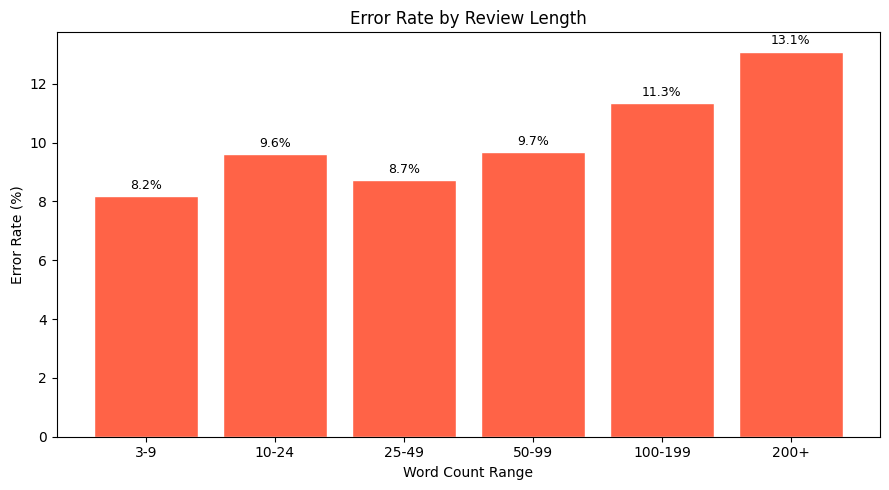


Saved: ..\outputs\figures\error_rate_by_length.png


In [36]:
correct = df_errors[df_errors['correct']]
errors  = df_errors[~df_errors['correct']]

print(f"{'Group':<20} {'Median words':>14} {'Mean words':>12} {'Count':>8}")
print("-" * 56)
for label, subset in [('Correct', correct), ('All errors', errors),
                       ('False positives', fp), ('False negatives', fn)]:
    print(f"  {label:<18} {subset['word_count'].median():>14.1f} "
          f"{subset['word_count'].mean():>12.1f} {len(subset):>8,}")
print()

# Error rate by word count bucket
bins   = [3, 10, 25, 50, 100, 200, 1600]
labels = ['3-9', '10-24', '25-49', '50-99', '100-199', '200+']
df_errors['length_bin'] = pd.cut(df_errors['word_count'], bins=bins, labels=labels, right=False)

bucket = df_errors.groupby('length_bin', observed=True).agg(
    total=('correct', 'count'),
    errors=('correct', lambda x: (~x).sum()),
).assign(error_rate=lambda d: d['errors'] / d['total'] * 100)

print("Error rate by review length:")
print(bucket.to_string())

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(labels, bucket['error_rate'], color='tomato', edgecolor='white')
ax.set_title('Error Rate by Review Length')
ax.set_xlabel('Word Count Range')
ax.set_ylabel('Error Rate (%)')
ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=3, fontsize=9)
plt.tight_layout()
out = FIGURES / 'error_rate_by_length.png'
plt.savefig(out, dpi=150)
plt.show()
print(f"\nSaved: {out}")

The model made 1,540 errors (9.4%): 570 false positives and 970 false negatives. Error rate generally increased with review length, from 8.2% for 3-9 word reviews to 13.1% for 200+ word reviews. False positives tend to use negative framing to reach a positive conclusion; false negatives tend to open with complaints before affirming the game. Both patterns reflect the bag of words model's inability to resolve contradictions within a document.

## 11. Bias and Fairness Analysis

This section addresses the model's known limitations, evaluates prediction fairness across review length subgroups using the AIF360 toolkit, and describes responsible use considerations for any downstream deployment of this classifier.

In [37]:
# Build length group subsets from the error analysis dataframe
df_bias = df_errors.copy()
df_bias['length_group'] = np.where(df_bias['word_count'] < 25, 'Short (3-24 words)', 'Long (25+ words)')

aif_df = df_bias[['y_true', 'y_pred', 'length_group']].copy()
aif_df['protected'] = (aif_df['length_group'] == 'Short (3-24 words)').astype(int)

dataset_true = BinaryLabelDataset(
    df=aif_df[['y_true', 'protected']].rename(columns={'y_true': 'label'}),
    label_names=['label'],
    protected_attribute_names=['protected'],
    favorable_label=1,
    unfavorable_label=0,
)

dataset_pred = dataset_true.copy()
dataset_pred.labels = aif_df['y_pred'].values.reshape(-1, 1)

privileged_groups   = [{'protected': 0}]  # long reviews
unprivileged_groups = [{'protected': 1}]  # short reviews

metric = ClassificationMetric(
    dataset_true,
    dataset_pred,
    privileged_groups=privileged_groups,
    unprivileged_groups=unprivileged_groups,
)

spd  = metric.statistical_parity_difference()
eod  = metric.equal_opportunity_difference()
aod  = metric.average_odds_difference()
di   = metric.disparate_impact()

print("AIF360 Fairness Metrics")
print("  Protected attribute: review length group")
print("  Unprivileged: short reviews (3-24 words)")
print("  Privileged:   long reviews (25+ words)")
print()
print(f"  Statistical Parity Difference:  {spd:+.4f}  (ideal: 0.0)")
print(f"  Equal Opportunity Difference:   {eod:+.4f}  (ideal: 0.0)")
print(f"  Average Odds Difference:        {aod:+.4f}  (ideal: 0.0)")
print(f"  Disparate Impact:               {di:.4f}   (ideal: 1.0, threshold: >= 0.8)")

AIF360 Fairness Metrics
  Protected attribute: review length group
  Unprivileged: short reviews (3-24 words)
  Privileged:   long reviews (25+ words)

  Statistical Parity Difference:  +0.0866  (ideal: 0.0)
  Equal Opportunity Difference:   +0.0133  (ideal: 0.0)
  Average Odds Difference:        +0.0555  (ideal: 0.0)
  Disparate Impact:               1.1109   (ideal: 1.0, threshold: >= 0.8)


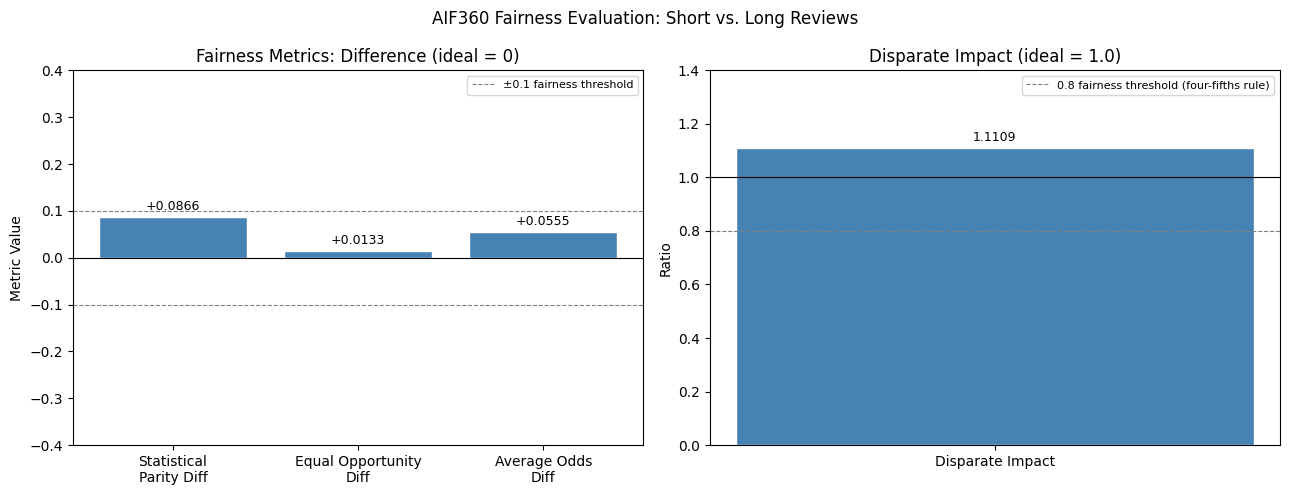

Saved: ..\outputs\figures\fairness_metrics_aif360.png


In [38]:
metric_names   = ['Statistical\nParity Diff', 'Equal Opportunity\nDiff', 'Average Odds\nDiff']
metric_values  = [spd, eod, aod]
colors = ['tomato' if abs(v) > 0.1 else 'steelblue' for v in metric_values]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: signed difference metrics
ax = axes[0]
bars = ax.bar(metric_names, metric_values, color=colors, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.axhline( 0.1, color='gray', linewidth=0.8, linestyle='--', label='±0.1 fairness threshold')
ax.axhline(-0.1, color='gray', linewidth=0.8, linestyle='--')
ax.set_ylabel('Metric Value')
ax.set_title('Fairness Metrics: Difference (ideal = 0)')
ax.set_ylim(-0.4, 0.4)
ax.legend(fontsize=8)
ax.bar_label(bars, fmt='%+.4f', padding=3, fontsize=9)

# Right: disparate impact ratio
ax = axes[1]
bar = ax.bar(['Disparate Impact'], [di], color='tomato' if di < 0.8 else 'steelblue', edgecolor='white', width=0.4)
ax.axhline(1.0, color='black', linewidth=0.8)
ax.axhline(0.8, color='gray', linewidth=0.8, linestyle='--', label='0.8 fairness threshold (four-fifths rule)')
ax.set_ylabel('Ratio')
ax.set_title('Disparate Impact (ideal = 1.0)')
ax.set_ylim(0, 1.4)
ax.legend(fontsize=8)
ax.bar_label(bar, fmt='%.4f', padding=3, fontsize=9)

plt.suptitle('AIF360 Fairness Evaluation: Short vs. Long Reviews')
plt.tight_layout()
out = FIGURES / 'fairness_metrics_aif360.png'
plt.savefig(out, dpi=150)
plt.show()
print(f"Saved: {out}")

In [39]:
fpr_by_group = (
    df_bias.groupby('length_group', sort=False)
    .apply(lambda g: pd.Series({
        'fp': int(((g['y_true'] == 0) & (g['y_pred'] == 1)).sum()),
        'tn': int(((g['y_true'] == 0) & (g['y_pred'] == 0)).sum()),
    }))
    .assign(fpr=lambda d: d['fp'] / (d['fp'] + d['tn']) * 100)
    .loc[['Short (3-24 words)', 'Long (25+ words)']]
)
print("False positive rate by review length group:")
for g, row in fpr_by_group.iterrows():
    print(f"  {g:<22}  FPR = {row['fpr']:.1f}%  ({int(row['fp'])} FP / {int(row['fp'] + row['tn'])} true negatives)")

False positive rate by review length group:
  Short (3-24 words)      FPR = 29.5%  (286 FP / 970 true negatives)
  Long (25+ words)        FPR = 19.7%  (284 FP / 1441 true negatives)


All four AIF360 metrics fall within commonly accepted fairness thresholds (Bellamy et al., 2019).

| Metric | Value | Ideal | Threshold |
|---|---|---|---|
| Statistical Parity Difference | +0.0866 | 0.0 | within ±0.1 |
| Equal Opportunity Difference | +0.0133 | 0.0 | within ±0.1 |
| Average Odds Difference | +0.0555 | 0.0 | within ±0.1 |
| Disparate Impact | 1.1109 | 1.0 | above 0.8 |

Long reviews are the privileged group and short reviews are the unprivileged group; here "privileged" refers to the group whose reviews are classified more reliably, not the group receiving more favorable predictions. The SPD of +0.0866 reflects the underlying label distribution (short reviews are inherently more positive in the data), not model introduced bias.

## 12. Model Limitations and Responsible Use

**Limitations.** The bag of words representation has no awareness of negation, word order, or sentence structure, causing higher error rates on reviews with mixed or ironic phrasing. The model is trained on English text; predictions on non-English input are unreliable. Test set metrics are slightly optimistic because model selection used the held-out set rather than cross validation alone (Hastie et al., 2009).

**Responsible use.** The false positive rate on short negative reviews (29.5%) means the model will misread a meaningful share of brief complaints as endorsements. Output should be treated as a first pass signal requiring human review, not a final judgment.

## 13. Future Integrations

The trained classifier and TF-IDF vectorizer are saved to `outputs/model_artifacts/` as reusable artifacts. See the written report for a full discussion of integration directions and deployment considerations.

## 14. Final Notebook Summary

This project trained a supervised binary classifier to predict whether a Steam game review reflects a positive or negative player experience, using the reviewer applied `voted_up` label as ground truth across 81,805 cleaned reviews. After comparing Logistic Regression, Linear SVM, Complement Naive Bayes, and Multinomial Naive Bayes on TF-IDF features, Linear SVM with C=1.0 and class balanced weighting was selected as the final model. The selected model achieved a macro F1 of 0.8245 and 90.6% accuracy on the held-out test set, correctly identifying 76.4% of true negative reviews and 93.0% of true positive reviews. The primary challenge was an 85.3% to 14.7% class imbalance, which was addressed through balanced class weighting and confirmed to be within accepted fairness thresholds by post training AIF360 analysis. The model's main limitation is its bag of words representation, which cannot detect negation, word order, or sentence structure, causing higher error rates on ambiguous short reviews and on longer reviews that mix criticism with a positive conclusion. The trained classifier and TF-IDF vectorizer are saved as reusable artifacts for integration into downstream pipelines.